In [2]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, r2_score
from qiskit import QuantumCircuit
from qiskit.circuit.library import pauli_feature_map
from qiskit_aer import AerSimulator
from qiskit_machine_learning.algorithms import QSVR
from qiskit_machine_learning.kernels import FidelityQuantumKernel

In [ ]:
gevrey_method_features = pd.read_csv("../results/gevrey_method_feature_selection.csv")["feature"].tolist()
features = gevrey_method_features[:10]
print(features)
print(len(features))

['z_cogram', 'z_gram_lag_1', 'z_gram_lag_5', 'z_gram_lag_7', 'z_gram_lag_10', 'z_gram_lag_9', 'd_lag_1', 'z_gram_lag_4', 'z_gram_lag_6', 'z_gram_lag_3', 'z_gram_lag_2', 'z_gram_lag_8', 'd_lag_2', 'z_gram']
14


In [4]:
class DatasetScalerService:
    MAX_LIMIT = 100_000
    def __init__(self, features: list[str]):
        self.__scaler_X = StandardScaler()
        self.__X_original = pd.read_csv("../dataset/j_kampe.csv")
        self.__y_original = pd.read_csv("../dataset/distances.csv")["distance"]
        self.__features = features

    def get_scaled_data(self, limit: int = 11_000):
        if limit > self.MAX_LIMIT:
            limit = self.MAX_LIMIT

        X = self.__X_original[self.__features].values
        y = self.__y_original.values.reshape(-1, 1)

        X = X[1_000:limit]
        y = y[1_000:limit]

        X_train = X[:int(0.8 * X.shape[0])]
        X_test  = X[int(0.8 * X.shape[0]):]
        y_train = y[:int(0.8 * y.shape[0])]
        y_test  = y[int(0.8 * y.shape[0]):]

        X_train_scaled = self.__scaler_X.fit_transform(X_train)
        X_test_scaled  = self.__scaler_X.transform(X_test)
        return X_train_scaled, X_test_scaled, y_train, y_test

In [5]:
def create_quantum_kernel(feature_dim: int, reps: int = 2, paulis: list[str]|None = None) -> tuple[QuantumCircuit, FidelityQuantumKernel]:
    '''
    feature_dim is the number of features in a datapoint
    reps in the depth of the pauli feature map circuit
    '''
    if paulis is None:
        paulis = ["Z", "ZZ"]

    feature_map = pauli_feature_map(
        feature_dimension=feature_dim,
        reps=reps,
        paulis=paulis,
        entanglement="linear"
    )

    feature_map.draw('mpl')

    quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)
    
    return feature_map, quantum_kernel 

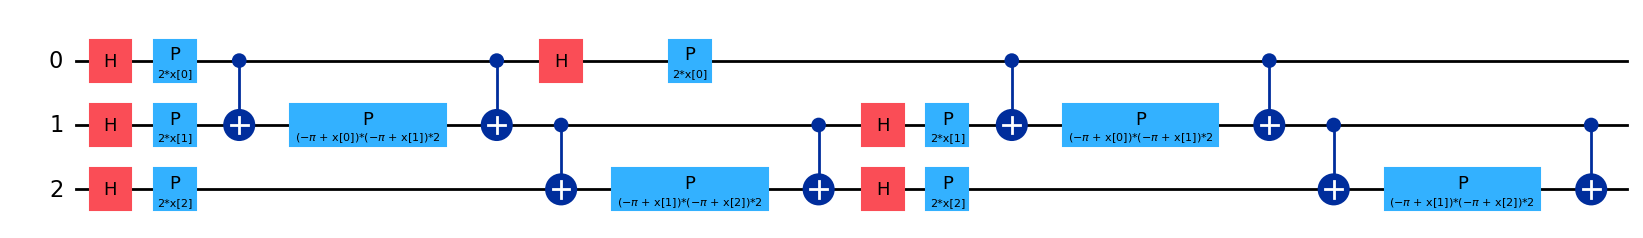

In [6]:
feature_map_circuit, quantum_kernel = create_quantum_kernel(feature_dim=3)

feature_map_circuit.draw('mpl')

In [ ]:
C = 10
epsilon = 0.001
n_qubits = len(features)

dataset_scaler_service = DatasetScalerService(features)
(
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
) = dataset_scaler_service.get_scaled_data(limit=1500)

_, quantum_kernel = create_quantum_kernel(
    feature_dim=n_qubits,
    reps=2,
)

print(f"Training QSVR with C={C}, epsilon={epsilon}...")

qsvr = QSVR(quantum_kernel=quantum_kernel, C=C, epsilon=epsilon)
qsvr.fit(X_train_scaled, y_train)

y_pred = qsvr.predict(X_test_scaled)

rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}, R²: {r2:.4f}")

results = {
    "Model": "QSVR",
    "Feature Map": "Pauli (Z, ZZ)",
    "Best RMSE": rmse,
    "R2": r2,
    "Best C": C,
    "Best Epsilon": epsilon,
    "Features": n_qubits
}

qsvr_df = pd.DataFrame([results]).sort_values("Best RMSE").reset_index(drop=True)
print(qsvr_df)
qsvr_df.to_csv("../results/qsvr_results_v1.csv", index=False)

Training QSVR with C=10, epsilon=0.001...


/home/gabriel/Documents/ic_qc/rgpe/venv/lib64/python3.13/site-packages/sklearn/svm/_base.py:308: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  return column_or_1d(y, warn=True).astype(np.float64, copy=False)
